Juan Fernando Serrano

Harrizon Alonso

Juan Pablo Jimenez

In [8]:
import boto3
from botocore.exceptions import ClientError

BUCKET = "juanpablojimenez"       # <-- reemplaza
PREFIX = "raw_zone/weather/"

s3 = boto3.client("s3")

# Evidencia de que las credenciales vienen del rol de la instancia (LabInstanceProfile)
creds = boto3.Session().get_credentials()
print("Método de credenciales:", creds.method)   # esperado: iam-role
print("Región:", s3.meta.region_name)

Método de credenciales: iam-role
Región: us-east-1


In [3]:
paginator = s3.get_paginator("list_objects_v2")

archivos = []
for page in paginator.paginate(Bucket=BUCKET, Prefix=PREFIX):
    for obj in page.get("Contents", []):
        if obj["Key"].endswith("/"):      # ignora el "folder" vacío
            continue
        archivos.append(obj)

print(f"Archivos encontrados en s3://{BUCKET}/{PREFIX}: {len(archivos)}\n")

for obj in sorted(archivos, key=lambda o: o["LastModified"]):
    print(f"{obj['LastModified']:%Y-%m-%d %H:%M:%S UTC}  {obj['Size']:>8,} B  {obj['Key']}")

Archivos encontrados en s3://juanpablojimenez/raw_zone/weather/: 4

2026-08-22 16:25:27 UTC       120 B  raw_zone/weather/weather-data_20260822162526.csv
2026-08-26 01:35:06 UTC       119 B  raw_zone/weather/weather-data_20260826013505.csv
2026-08-26 01:40:05 UTC       119 B  raw_zone/weather/weather-data_20260826014004.csv
2026-08-26 01:45:05 UTC       119 B  raw_zone/weather/weather-data_20260826014504.csv


In [10]:
import os
import io
import boto3
import pandas as pd
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()
bucket_name = os.getenv("BUCKET_NAME")

# Create S3 client (no explicit credentials needed, thanks to LabInstanceProfile)
s3_client = boto3.client('s3', region_name='us-east-1')

# List all objects under the raw-zone/weather prefix
prefix = "raw_zone/weather/"
response = s3_client.list_objects_v2(Bucket=bucket_name, Prefix=prefix)

dataframes = []

if "Contents" in response:
    for obj in response["Contents"]:
        key = obj["Key"]
        # Skip folder placeholders (0-byte "directory" objects), if any
        if key.endswith("/"):
            continue

        # Read the object body directly into memory (no disk writes)
        s3_object = s3_client.get_object(Bucket=bucket_name, Key=key)
        csv_bytes = s3_object["Body"].read()
        df = pd.read_csv(io.BytesIO(csv_bytes))
        dataframes.append(df)
else:
    print(f"No objects found under s3://{bucket_name}/{prefix}")

if dataframes:
    # Consolidate all readings into a single DataFrame
    consolidated_df = pd.concat(dataframes, ignore_index=True)

    # Compute basic summary statistics
    num_readings = len(consolidated_df)
    avg_temp = consolidated_df["temperature_C"].mean()
    min_humidity = consolidated_df["humidity_pct"].min()
    max_humidity = consolidated_df["humidity_pct"].max()

    print(f"Number of readings collected: {num_readings}")
    print(f"Average temperature (C): {avg_temp:.2f}")
    print(f"Minimum humidity (%): {min_humidity}")
    print(f"Maximum humidity (%): {max_humidity}")
else:
    print("No data available to consolidate.")

Number of readings collected: 4
Average temperature (C): 14.25
Minimum humidity (%): 62
Maximum humidity (%): 86


In [11]:
consolidated_df.describe()

,temperature_C,humidity_pct,wind_speed_ms
count,4.000,4.0,4.000000
mean,14.245,68.0,2.380000
std,0.890,12.0,1.208636
min,13.800,62.0,1.320000
25%,13.800,62.0,1.860000
50%,13.800,62.0,2.040000
75%,14.245,68.0,2.560000
max,15.580,86.0,4.120000


In [12]:
consolidated_df.head()

,extraction_date,temperature_C,humidity_pct,weather_desc,wind_speed_ms
0,2026-08-22 16:25:26,15.58,86,overcast clouds,1.32
1,2026-08-26 01:35:05,13.80,62,overcast clouds,4.12
2,2026-08-26 01:40:04,13.80,62,overcast clouds,2.04
3,2026-08-26 01:45:04,13.80,62,overcast clouds,2.04


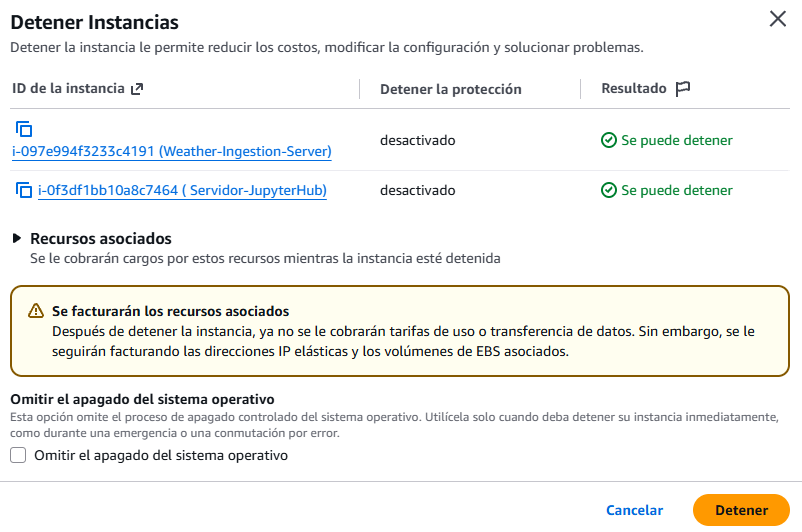

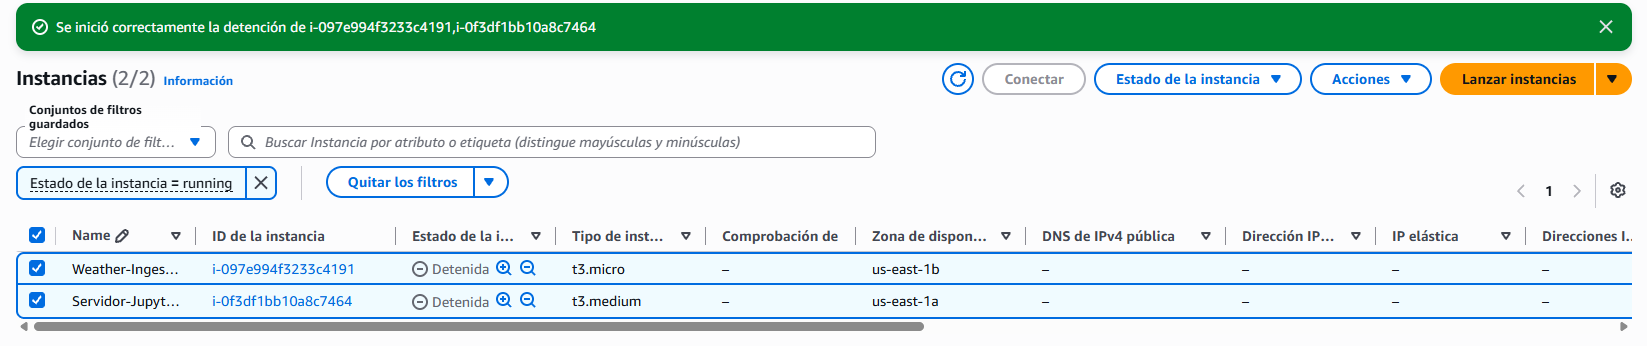